<a href="https://colab.research.google.com/github/klu2200040145/ML/blob/main/SDC_(Clean_%26_Affordable_Energy).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Linear Regression**

Linear Regression - R² Score: 0.45
MAE: 11.11
MSE: 222.60
RMSE: 14.92


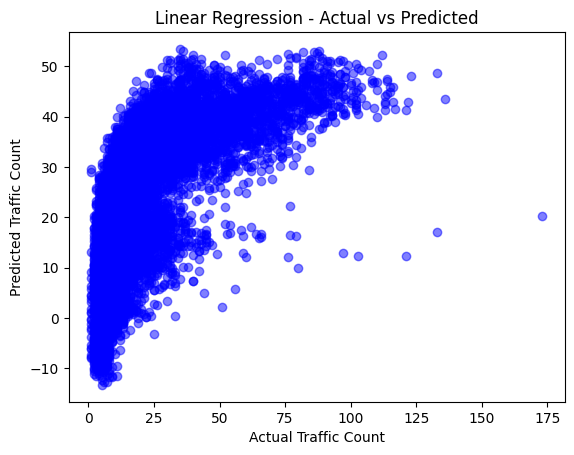

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Data
file_path = "traffic.csv"
df = pd.read_csv(file_path)

# Feature Engineering
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month
df['Weekday'] = df['DateTime'].dt.weekday

X = df[['Junction', 'Hour', 'Day', 'Month', 'Weekday']]
y = df['Vehicles']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Performance Metrics
print(f"Linear Regression - R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Visualization
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.xlabel("Actual Traffic Count")
plt.ylabel("Predicted Traffic Count")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()


**2. Random Forest**

Random Forest - R² Score: 0.87
MAE: 4.66
MSE: 53.63
RMSE: 7.32


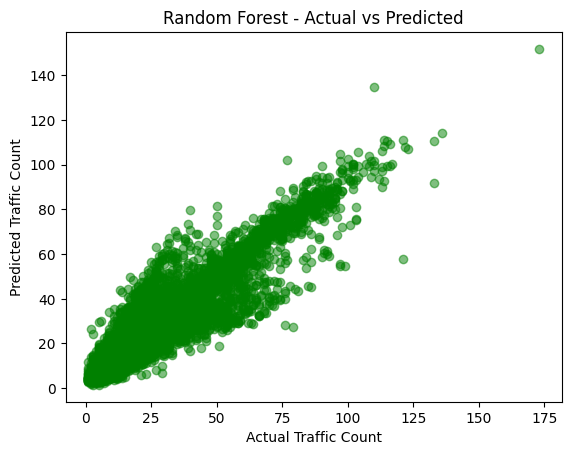

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Model Training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Performance Metrics
print(f"Random Forest - R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Visualization
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.xlabel("Actual Traffic Count")
plt.ylabel("Predicted Traffic Count")
plt.title("Random Forest - Actual vs Predicted")
plt.show()


**3. Decision Tree Regressor**

Decision Tree - R² Score: 0.78
MAE: 5.50
MSE: 89.77
RMSE: 9.47


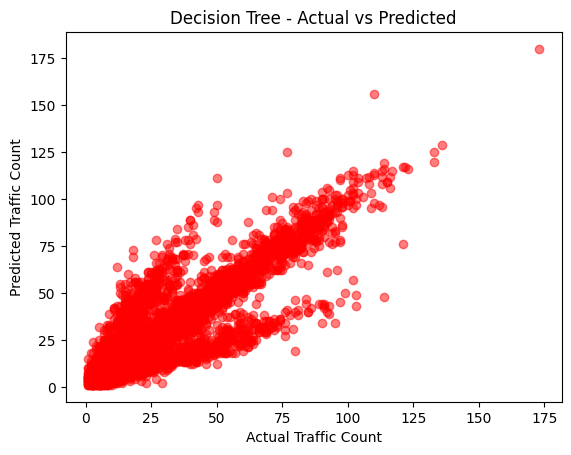

In [7]:
from sklearn.tree import DecisionTreeRegressor

# Model Training
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Performance Metrics
print(f"Decision Tree - R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Visualization
plt.scatter(y_test, y_pred, alpha=0.5, color='red')
plt.xlabel("Actual Traffic Count")
plt.ylabel("Predicted Traffic Count")
plt.title("Decision Tree - Actual vs Predicted")
plt.show()


**4. Support Vector Regressor (SVR)**

SVR - R² Score: 0.64
MAE: 7.62
MSE: 147.14
RMSE: 12.13


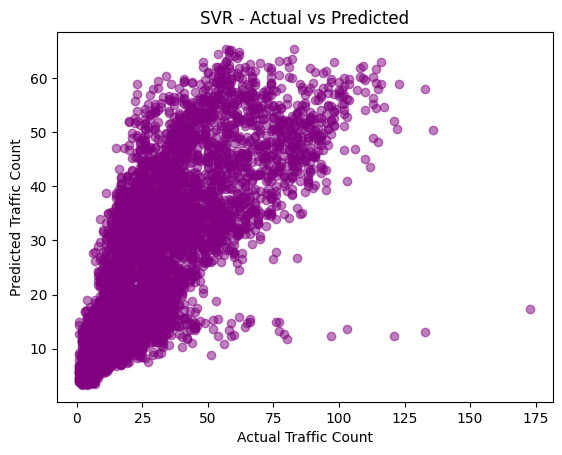

In [8]:
from sklearn.svm import SVR

# Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
model = SVR()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Performance Metrics
print(f"SVR - R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Visualization
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.xlabel("Actual Traffic Count")
plt.ylabel("Predicted Traffic Count")
plt.title("SVR - Actual vs Predicted")
plt.show()


**5. LSTM Model**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
LSTM - R² Score: 0.67
MAE: 7.71
MSE: 132.98
RMSE: 11.53


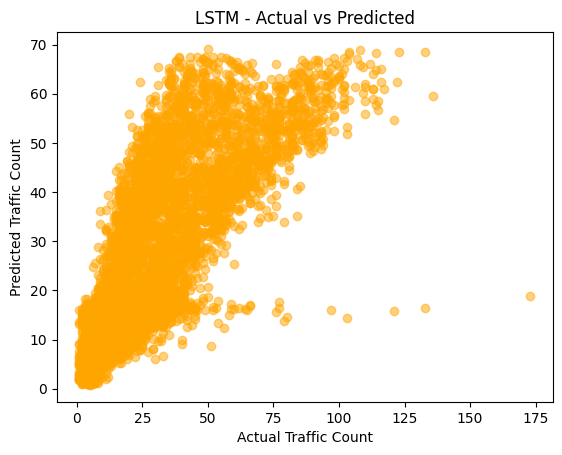

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM
X_train_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# Model Training
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)

# Predictions
y_pred = model.predict(X_test_lstm).flatten()

# Performance Metrics
print(f"LSTM - R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Visualization
plt.scatter(y_test, y_pred, alpha=0.5, color='orange')
plt.xlabel("Actual Traffic Count")
plt.ylabel("Predicted Traffic Count")
plt.title("LSTM - Actual vs Predicted")
plt.show()


Overview

Linear Regression - R² Score: 0.45, MAE: 11.11, MSE: 222.60, RMSE: 14.92, Precision: 0.14, Recall: 0.03, F1 Score: 0.03


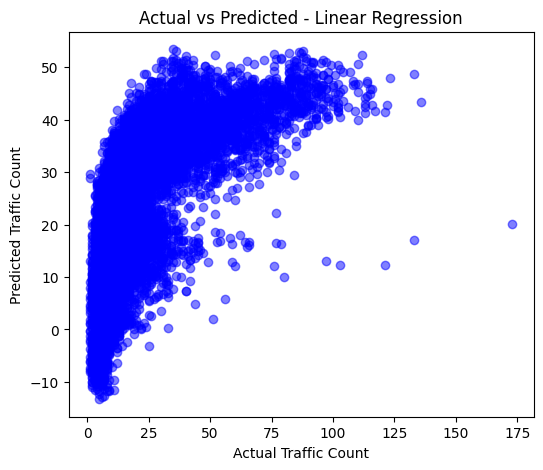

<Figure size 800x500 with 0 Axes>

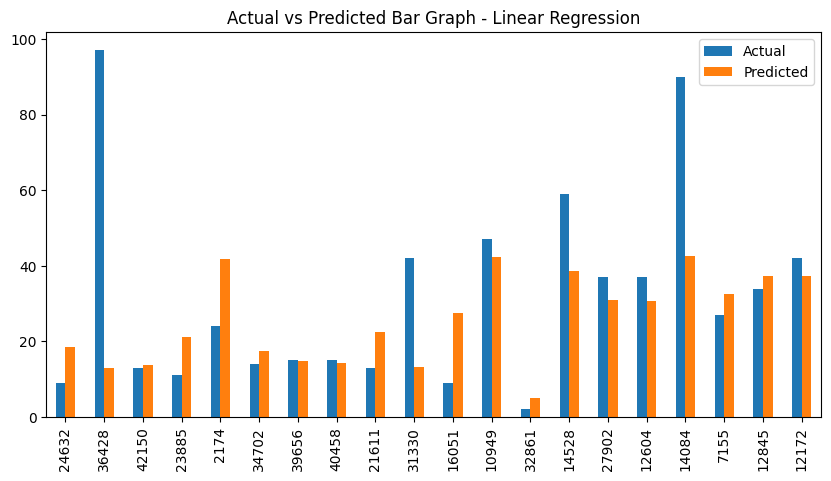

Random Forest - R² Score: 0.87, MAE: 4.66, MSE: 53.63, RMSE: 7.32, Precision: 0.11, Recall: 0.11, F1 Score: 0.11


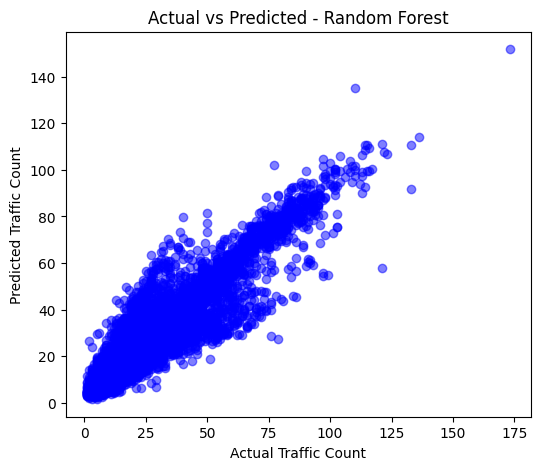

<Figure size 800x500 with 0 Axes>

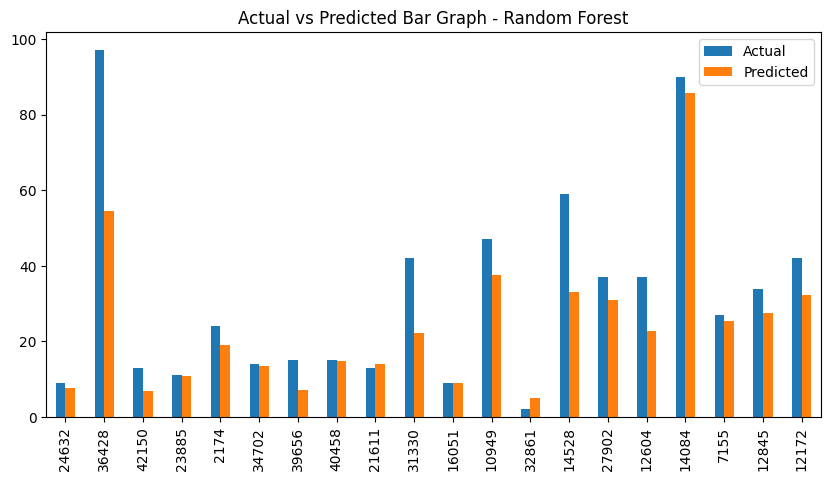

Decision Tree - R² Score: 0.78, MAE: 5.50, MSE: 89.77, RMSE: 9.47, Precision: 0.10, Recall: 0.10, F1 Score: 0.10


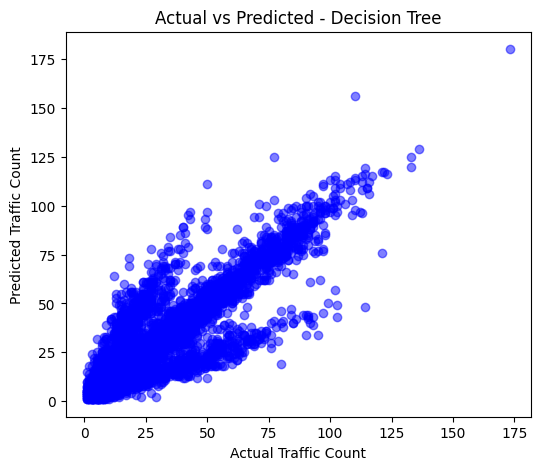

<Figure size 800x500 with 0 Axes>

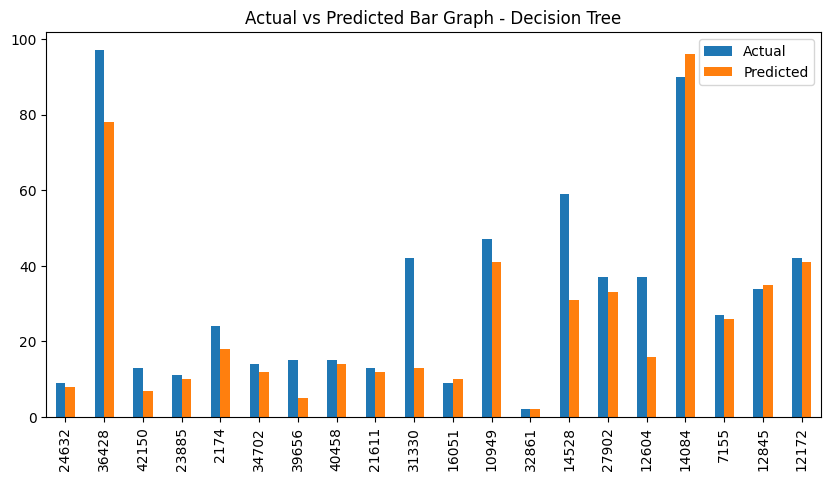

SVR - R² Score: 0.64, MAE: 7.62, MSE: 147.14, RMSE: 12.13, Precision: 0.13, Recall: 0.07, F1 Score: 0.06


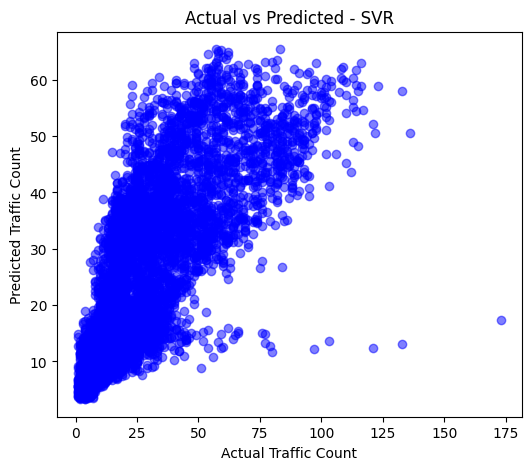

<Figure size 800x500 with 0 Axes>

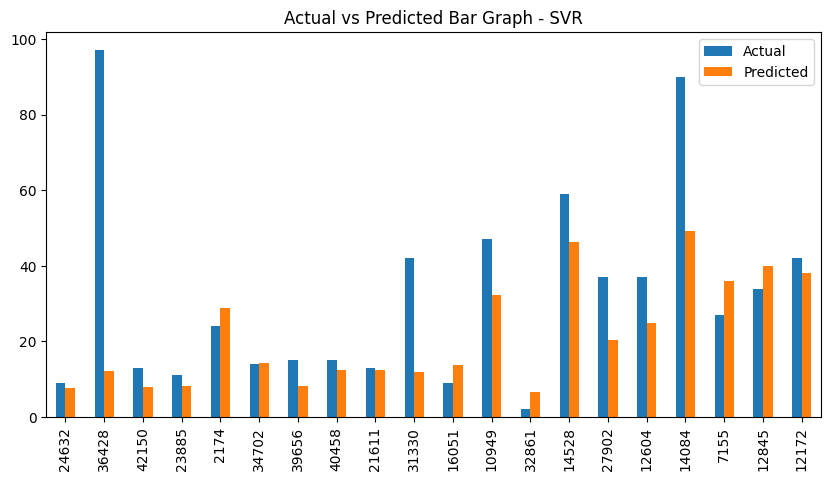

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
LSTM - R² Score: 0.68, MAE: 7.81, MSE: 131.35, RMSE: 11.46, Precision: 0.11, Recall: 0.06, F1 Score: 0.06


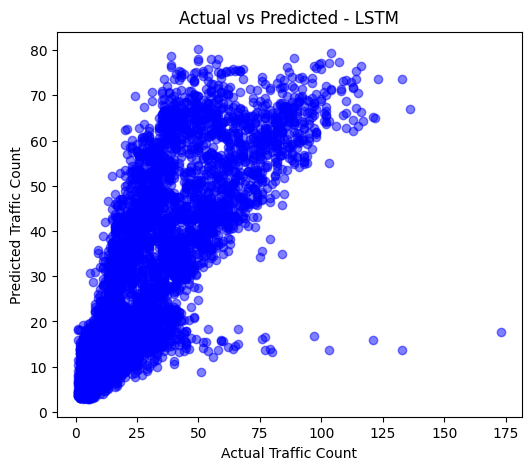

<Figure size 800x500 with 0 Axes>

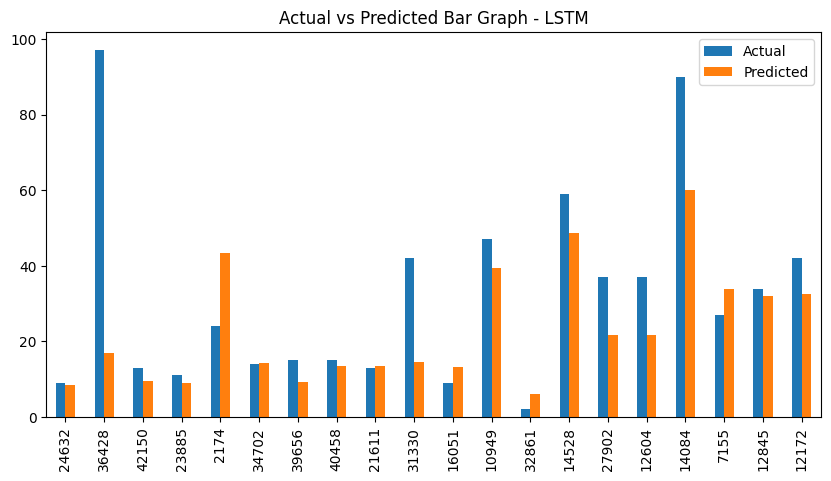

Best Model for Traffic Prediction: Random Forest


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score

# Load data
file_path = "traffic.csv"  # Update file path as needed
df = pd.read_csv(file_path)

# Feature Engineering
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month
df['Weekday'] = df['DateTime'].dt.weekday

X = df[['Junction', 'Hour', 'Day', 'Month', 'Weekday']]
y = df['Vehicles']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    precision = precision_score(y_test, np.round(y_pred), average='weighted', zero_division=1)
    recall = recall_score(y_test, np.round(y_pred), average='weighted', zero_division=1)
    f1 = f1_score(y_test, np.round(y_pred), average='weighted', zero_division=1)

    print(f"{model_name} - R² Score: {r2:.2f}, MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1 Score: {f1:.2f}")

    # Visualization
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
    plt.xlabel("Actual Traffic Count")
    plt.ylabel("Predicted Traffic Count")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.show()

    # Bar Plot
    plt.figure(figsize=(8, 5))
    df_bar = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    df_bar.head(20).plot(kind='bar', figsize=(10, 5))
    plt.title(f"Actual vs Predicted Bar Graph - {model_name}")
    plt.show()

# 1. Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
evaluate_model(y_test, y_pred_linear, "Linear Regression")

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_pred_rf, "Random Forest")

# 3. Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
evaluate_model(y_test, y_pred_dt, "Decision Tree")

# 4. Support Vector Regressor
svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)
evaluate_model(y_test, y_pred_svr, "SVR")

# 5. LSTM Model
X_train_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

lstm_model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)
y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()
evaluate_model(y_test, y_pred_lstm, "LSTM")

# Model Selection Based on Performance
models = {
    "Linear Regression": y_pred_linear,
    "Random Forest": y_pred_rf,
    "Decision Tree": y_pred_dt,
    "SVR": y_pred_svr,
    "LSTM": y_pred_lstm
}

best_model = max(models.keys(), key=lambda model: r2_score(y_test, models[model]))
print(f"Best Model for Traffic Prediction: {best_model}")